In [1]:
import ui
import construct
import ifc

import ui.comms

from system_config import *
from construction_config import *

import construct.analysis as analysis
 
from ui.mobility import moveJ, moveL, translate, set_orientation, gripper_width
# from construct.marker_pose import align_with_random_part
from construct.construction import rotation_matrix_to_vector
import ui.MarkerDetectionLocalization as mdl
# import time
# ui.show_project_structure()

HERE!!!

[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Subscribed to topic: /image
Robot data listener started on tcp://127.0.0.1:5560...
Listening for tracking messages...
[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Subscribed to topic: /image


{'coordinates': [-0.159, -0.334, 0.332],
 'element': None,
 'state': None,
 'joints': [0.7364310026168823,
  -1.877449174920553,
  2.2459104696856897,
  -1.9905439815916957,
  -1.4977877775775355,
  -0.7160604635821741],
 'orientation': [[-0.9933832249719409,
   0.11347120010340549,
   -0.01772159957337894],
  [0.1145662485802232, 0.9898660637106718, -0.08390322163179932],
  [0.008021410761255048, -0.08537835007209522, -0.9963163123769309]],
 'worker spotted': False,
 'timestamp_send': 1744706697.9574778,
 'obstacle_maneuver': False}

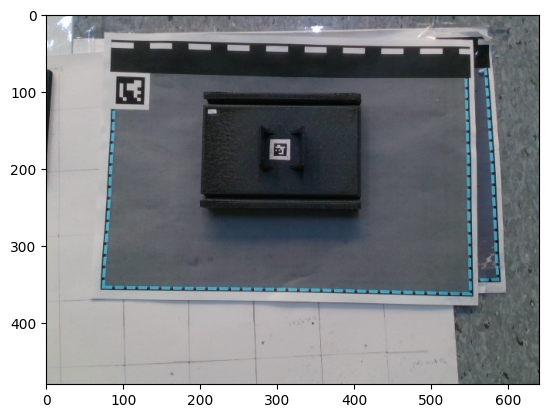

In [2]:
framehandler = ui.initializeUI()
packet = ui.comms.get_current_packet()
packet

In [3]:
# Assembly 
ui.comms.refresh_tracking_packets() #Refresh stored data
script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v1.ifc", "--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

# idx = construct.check_continue()
idx = 0

item_list, block_list, pl_pos = construct.perform_construction(IFC_sorted, framehandler, idx,use_stub= False)
assembly_data = ui.load_data(10) 

Performing site scan
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Searching for Foundation
The item is here:
Unable to find fiducial marker. Please check the setup.
Initiating bathroom routine for associated element.
We should now place a colored toilet!
Red found = True
Blue found = True
Searching for Wall_1
The item is here:
Unable to find fiducial marker. Please check the setup.
Searching for Floor_1
The item is here:
Unable to find fiducial marker. Please check the setup.
Initiating bathroom routine for associated element.
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on floor
Second bathroom
Searching for Wall_2
The item is here:
Unable to find fiducial marker. Please check the setup.
Searching for Floor_2
The item is here:
Unable to find fiducial marker. Please check the setup.
second floor
Initiating bathroom routine

In [ ]:
# Disassembly 
ui.comms.refresh_tracking_packets() #Refresh stored data


construct.disassembly(item_list, pl_pos, block_list, framehandler)
disassembly_data = ui.load_data(10)

Using stub file for site scan
Unable to find fiducial marker. Please check the setup.
Disassembly completed.


In [ ]:
# Reassembly 
ui.comms.refresh_tracking_packets() #Refresh stored data

#Assembly 2
script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

# idx = construct.check_continue()
idx = 0

item_list, block_list, pl_pos = construct.perform_reconstruction(IFC_sorted,framehandler, idx)
reassembly_data = ui.load_data(10)

Using stub file for site scan
Foundation
Searching for Foundation
Skipping placement for Foundation but continuing with the toilet routine.
We should now place a colored toilet!
Red found= True
Blue found= True
b
n_placed is: 0
Toilet is now placed!
Now placed all good!
Wall
Searching for Wall
The item is here:
Unable to find fiducial marker. Please check the setup.
I have now grabbed it!
We are now placing:
Now placed all good!
Floor
Searching for Floor
The item is here:
We can't see the correct marker!
Debug: Calculated angle: 0
I have now grabbed it!
We are now placing:
We should now place a colored toilet!
Red found= True
Blue found= True
r
n_placed is: 2
Placing toilet on floor
Second bathroom
Toilet is now placed!
Now placed all good!
Wall
Searching for Wall
The item is here:
Unable to find fiducial marker. Please check the setup.
I have now grabbed it!
We are now placing:
Now placed all good!
Floor
Searching for Floor
The item is here:
Unable to find fiducial marker. Please chec

In [4]:
import pickle
import os

data_dir = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_construction_data'

# Save variables only if they exist and are not None
if 'assembly_data' in locals() and assembly_data is not None:
    with open(os.path.join(data_dir, 'assembly_data.pkl'), 'wb') as f:
        pickle.dump(assembly_data, f)
        print("[Info] assembly_data saved...")

if 'disassembly_data' in locals() and disassembly_data is not None:
    with open(os.path.join(data_dir, 'disassembly_data.pkl'), 'wb') as f:
        pickle.dump(disassembly_data, f)
        print("[Info] disassembly_data saved...")

if 'reassembly_data' in locals() and reassembly_data is not None:
    with open(os.path.join(data_dir, 'reassembly_data.pkl'), 'wb') as f:
        pickle.dump(reassembly_data, f)
        print("[Info] reassembly_data  saved...")

print("[Info] Files saved successfully!")

[Info] assembly_data saved...
[Info] disassembly_data saved...
[Info] reassembly_data  saved...
[Info] Files saved successfully!


In [ ]:
import ui

from system_config import *
from construction_config import *

import pickle
import os

# Load each pickle file
with open(os.path.join(data_dir, 'assembly_data.pkl'), 'rb') as f:
    assembly_data = pickle.load(f)

with open(os.path.join(data_dir, 'disassembly_data.pkl'), 'rb') as f:
    disassembly_data = pickle.load(f)

with open(os.path.join(data_dir, 'reassembly_data.pkl'), 'rb') as f:
    reassembly_data = pickle.load(f)

In [2]:
options_assembly = {
    "trajectory_analysis": True,
    "hazard_analysis": True,
    "detection_analysis": True,
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,
    "data": assembly_data
}

options_disassebly = {
    "trajectory_analysis": True,
    "hazard_analysis": False, # For disassebly this ALWAYS false
    "detection_analysis": False, # For disassebly this ALWAYS false
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,

    "data": disassembly_data
}

options_reassembly = {
    "trajectory_analysis": True,
    "hazard_analysis": False, # # For reassembly this ALWAYS false
    "detection_analysis": False, # For reassembly this ALWAYS false
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis": True,
    "data": reassembly_data
}

analyzed_results_assembly = ui.analyze_trajectory(options_assembly,"assembly")
path_assembly = ui.save_results(analyzed_results_assembly, assembly_data,'ct')
assembly_file = ui.create_construction_summary_html(path_assembly)

analyzed_results_disassebly = ui.analyze_trajectory(options_disassebly,"reassembly")
path_disassembly = ui.save_results(analyzed_results_disassebly, disassembly_data,'dis')
disassembly_file = ui.create_construction_summary_html(path_disassembly) 

analyzed_results_reassembly = ui.analyze_trajectory(options_reassembly,"reassembly")
path_reassembly = ui.save_results(analyzed_results_reassembly, reassembly_data,'rect')
reassembly_file = ui.create_construction_summary_html(path_reassembly) 

ui.open_html_in_browser(assembly_file)
ui.open_html_in_browser(disassembly_file)
ui.open_html_in_browser(reassembly_file)

[INFO] Starting trajectory analysis...
[INFO] Performing hazard event processing...
[INFO] Tabulating hazard events...
[INFO] Plotting hazard events...
[INFO] Summarizing trajectory metrics...
[INFO] Plotting velocity and acceleration...
[INFO] Trajectory analysis completed.
[INFO] Starting worker detection analysis...
[INFO] Worker detection analysis completed.
[INFO] Performing segment-wise analysis...
scanning_site
Foundation
bathroom_module_1
Wall_1
Floor_1
bathroom_module_2
Wall_2
Floor_2
bathroom_module_3
[INFO] Segment analysis completed.
[INFO] Plotting worker positions...
[INFO] Worker plotting completed.
[INFO] Plotting full trajectory run...
[INFO] Full run plot completed.
[INFO] All requested analyses completed.
Results saved in /home/avi/Desktop/robomason/_workingdata/_constructionruns/construction_run_00
[INFO] Starting trajectory analysis...
[INFO] Summarizing trajectory metrics...
[INFO] Plotting velocity and acceleration...
[INFO] Trajectory analysis completed.
[INFO] 

In [4]:
full_run_data = assembly_data
full_run_data.extend(disassembly_data)
full_run_data.extend(reassembly_data)

options_full_run = {
    "trajectory_analysis": False,
    "detection_analysis": True, 
    "plot_full_run": True,
    "segment_analysis": False,
    "plot_workers":True,
    "data": full_run_data
}

analyzed_results_full_run = ui.analyze_trajectory(options_full_run,"assembly")
path_full_run = ui.save_results(analyzed_results_full_run, full_run_data,'full')
full_run_file = ui.create_construction_summary_html(path_full_run)
ui.open_html_in_browser(full_run_file)

[INFO] Starting worker detection analysis...
[INFO] Worker detection analysis completed.
[INFO] Plotting worker positions...
[INFO] Worker plotting completed.
[INFO] Plotting full trajectory run...
[INFO] Full run plot completed.
[INFO] All requested analyses completed.
Results saved in /home/avi/Desktop/robomason/_workingdata/_fullruns/complete_construction_run_01
